# **INTEGRANTES**
Kenichi Caio Yamamoto - RM: 569815

Rodger Costa Rios - RM: 571438

# **CARREGAMENTO DE DADOS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('dataset.csv')

print(f"Telemetria carregada! Total de registros (segmentos de missão): {df.shape[0]}")
print(f"Quantidade de variáveis monitoradas: {df.shape[1]}\n")
print("✓ Ambiente configurado e dados preparados com sucesso!")

Telemetria carregada! Total de registros (segmentos de missão): 2123
Quantidade de variáveis monitoradas: 23

✓ Ambiente configurado e dados preparados com sucesso!


# **TABELAS**

## **TABELA DE FREQUÊNCIA PARA VARIÁVEL DISCRETA**

In [ ]:
fi_discreta = df['n_peaks'].value_counts().sort_index()

fr_discreta = df['n_peaks'].value_counts(normalize=True).sort_index() * 100

Fi_discreta = fi_discreta.cumsum()
Fr_discreta = fr_discreta.cumsum()

tabela_discreta = pd.DataFrame({
    'Frequência Absoluta (fi)': fi_discreta,
    'Frequência Relativa (fr %)': fr_discreta.round(2),
    'Freq. Absoluta Acumulada (Fi)': Fi_discreta,
    'Freq. Relativa Acumulada (Fr %)': Fr_discreta.round(2)
})

tabela_discreta.index.name = 'Quantidade de Picos (n_peaks)'

display(tabela_discreta)

,Frequência Absoluta (fi),Frequência Relativa (fr %),Freq. Absoluta Acumulada (Fi),Freq. Relativa Acumulada (Fr %)
Quantidade de Picos (n_peaks),,,,
1,1654,77.91,1654,77.91
2,313,14.74,1967,92.65
3,78,3.67,2045,96.33
4,21,0.99,2066,97.32
5,13,0.61,2079,97.93
6,11,0.52,2090,98.45
7,4,0.19,2094,98.63
8,2,0.09,2096,98.73
9,3,0.14,2099,98.87


## **TABELA DE FREQUÊNCIA PARA VARIÁVEL CONTÍNUA**

In [ ]:
n = len(df)
k = int(1 + np.log2(n))
print(f"O algoritmo definiu {k} faixas/classes de tempo com base nos {n} registros.\n")

classes_duration = pd.cut(df['duration'], bins=k)

fi_continua = classes_duration.value_counts().sort_index()
fr_continua = classes_duration.value_counts(normalize=True).sort_index() * 100
Fi_continua = fi_continua.cumsum()
Fr_continua = fr_continua.cumsum()

tabela_continua = pd.DataFrame({
    'Frequência Absoluta (fi)': fi_continua,
    'Frequência Relativa (fr %)': fr_continua.round(2),
    'Freq. Absoluta Acumulada (Fi)': Fi_continua,
    'Freq. Relativa Acumulada (Fr %)': Fr_continua.round(2)
})

tabela_continua.index.name = 'Intervalos de Duração (segundos)'

display(tabela_continua)

O algoritmo definiu 12 faixas/classes de tempo com base nos 2123 registros.



,Frequência Absoluta (fi),Frequência Relativa (fr %),Freq. Absoluta Acumulada (Fi),Freq. Relativa Acumulada (Fr %)
Intervalos de Duração (segundos),,,,
"(33.7, 143.333]",424,19.97,424,19.97
"(143.333, 251.667]",882,41.54,1306,61.52
"(251.667, 360.0]",345,16.25,1651,77.77
"(360.0, 468.333]",226,10.65,1877,88.41
"(468.333, 576.667]",124,5.84,2001,94.25
"(576.667, 685.0]",63,2.97,2064,97.22
"(685.0, 793.333]",28,1.32,2092,98.54
"(793.333, 901.667]",17,0.80,2109,99.34
"(901.667, 1010.0]",8,0.38,2117,99.72


# **GRÁFICOS**

## **GRÁFICO DE BARRAS DA VARIÁVEL DISCRETA**

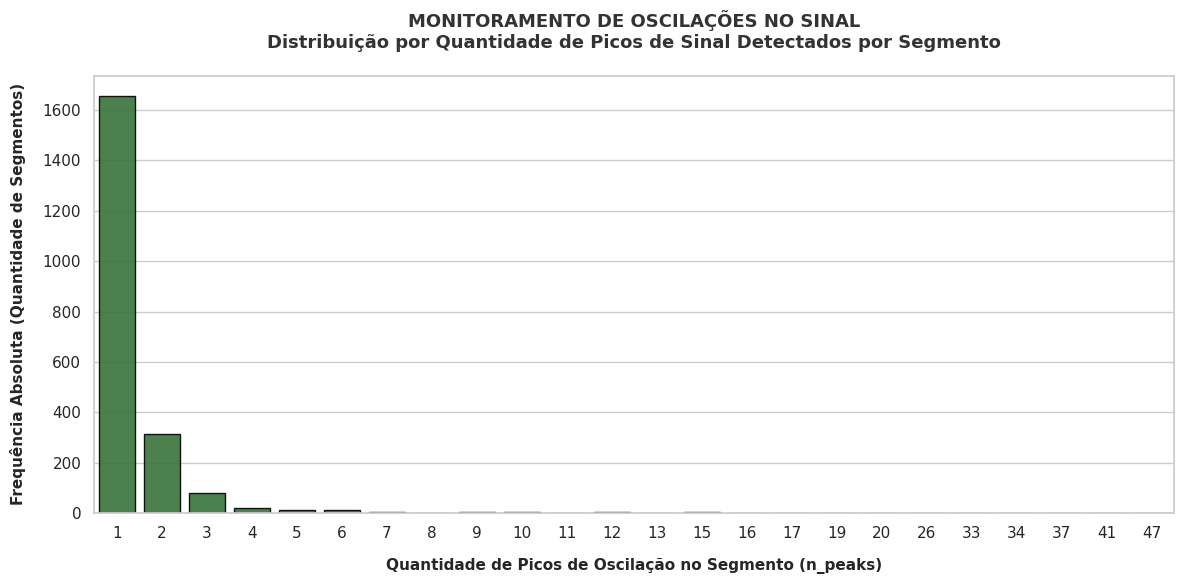

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

freq_discreta = df['n_peaks'].value_counts().sort_index()

sns.barplot(
    x=freq_discreta.index,
    y=freq_discreta.values,
    color='#2e7d32',
    edgecolor='#000000',
    alpha=0.9
)

plt.title('MONITORAMENTO DE OSCILAÇÕES NO SINAL\nDistribuição por Quantidade de Picos de Sinal Detectados por Segmento',
          fontsize=13, fontweight='bold', pad=20, color='#333333')

plt.xlabel('Quantidade de Picos de Oscilação no Segmento (n_peaks)', fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel('Frequência Absoluta (Quantidade de Segmentos)', fontsize=11, fontweight='bold', labelpad=12)

plt.tight_layout()

plt.show()

## **HISTOGRAMA DA VARIÁVEL CONTÍNUA**

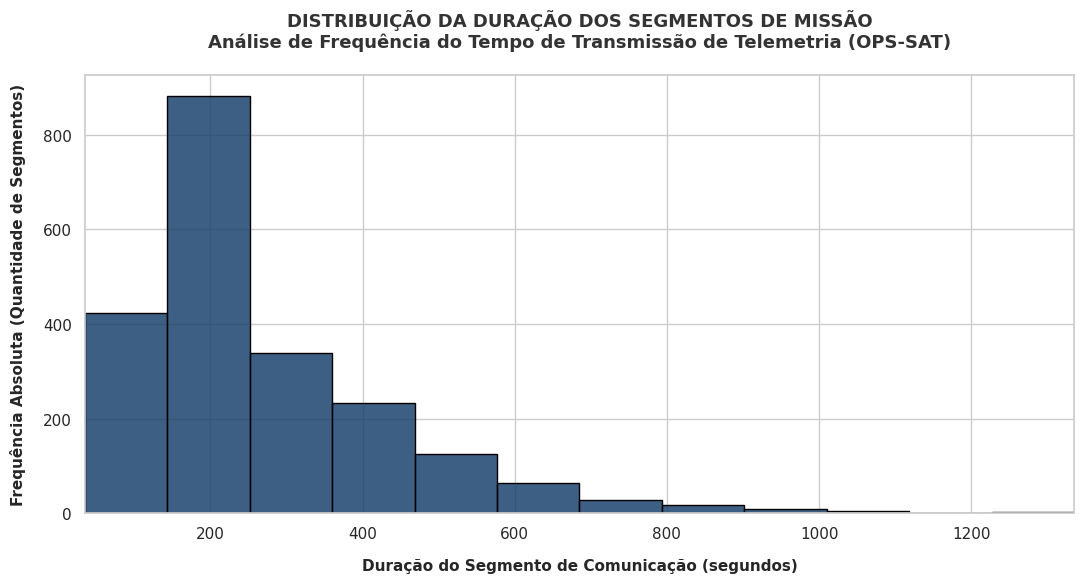

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

n = len(df)
k = int(1 + np.log2(n))

sns.histplot(
    data=df,
    x='duration',
    bins=k,
    color='#1a436d',
    edgecolor='#000000',
    alpha=0.85
)

plt.title('DISTRIBUIÇÃO DA DURAÇÃO DOS SEGMENTOS DE MISSÃO\nAnálise de Frequência do Tempo de Transmissão de Telemetria (OPS-SAT)',
          fontsize=13, fontweight='bold', pad=20, color='#333333')

plt.xlabel('Duração do Segmento de Comunicação (segundos)', fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel('Frequência Absoluta (Quantidade de Segmentos)', fontsize=11, fontweight='bold', labelpad=12)

plt.xlim(df['duration'].min(), df['duration'].max())

plt.tight_layout()

plt.show()

# **MEDIDAS ESTATÍSTICAS**

In [28]:
media_peaks = df['n_peaks'].mean()
moda_peaks = df['n_peaks'].mode()[0]
mediana_peaks = df['n_peaks'].median()

media_dur = df['duration'].mean()
moda_dur = df['duration'].mode()[0]
mediana_dur = df['duration'].median()


min_peaks = df['n_peaks'].min()
max_peaks = df['n_peaks'].max()
amplitude_peaks = max_peaks - min_peaks
variancia_peaks = df['n_peaks'].var()
desvio_peaks = df['n_peaks'].std()

min_dur = df['duration'].min()
max_dur = df['duration'].max()
amplitude_dur = max_dur - min_dur
variancia_dur = df['duration'].var()
desvio_dur = df['duration'].std()

q1_peaks = df['n_peaks'].quantile(0.25)
q3_peaks = df['n_peaks'].quantile(0.75)

q1_dur = df['duration'].quantile(0.25)
q3_dur = df['duration'].quantile(0.75)

medidas = pd.DataFrame({
    'Métrica Estatística': [
        'Média Aritmética',
        'Moda',
        'Mediana',
        'Valor Mínimo',
        'Valor Máximo',
        'Amplitude Total',
        'Variância',
        'Desvio Padrão',
        'Quartil 1 (Q1 - 25%)',
        'Quartil 3 (Q3 - 75%)'
    ],
    'Quantidade de Picos (n_peaks)': [
        media_peaks, moda_peaks, mediana_peaks,
        min_peaks, max_peaks, amplitude_peaks, variancia_peaks, desvio_peaks,
        q1_peaks, q3_peaks
    ],
    'Duração (duration - segundos)': [
        media_dur, moda_dur, mediana_dur,
        min_dur, max_dur, amplitude_dur, variancia_dur, desvio_dur,
        q1_dur, q3_dur
    ]
})

pd.options.display.float_format = '{:.4f}'.format

display(medidas)

,Métrica Estatística,Quantidade de Picos (n_peaks),Duração (duration - segundos)
0,Média Aritmética,1.5412,265.6138
1,Moda,1.0000,75.0000
2,Mediana,1.0000,225.0000
3,Valor Mínimo,1.0000,35.0000
4,Valor Máximo,47.0000,1335.0000
5,Amplitude Total,46.0000,1300.0000
6,Variância,5.7216,27941.9808
7,Desvio Padrão,2.3920,167.1585
8,Quartil 1 (Q1 - 25%),1.0000,175.0000
9,Quartil 3 (Q3 - 75%),1.0000,330.0000
